# House Price Prediction —  XYlofy AI Week 1 Internship Project

**Project:** Predicting house prices from property features using regression models.

🎯 Problem Statement

 Real estate buyers and sellers often rely on guesswork or outdated comparisons to estimate a property's fair value. Your task is to build a regression model that predicts house prices based on property features such as size, number of rooms, location, and age — and then identify which features most strongly influence price.
You will work with a real-world housing dataset, clean and prepare the data, train a regression model, evaluate its accuracy, and present your findings through charts and a short report.

**Dataset:** Housing Prices Dataset (Kaggle, by yasserh) — 545 properties, 13 features.

[Link](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

This notebook covers:
1. Data Loading & Exploration
2. Data Cleaning
3. Model Building (Linear Regression & Random Forest)
4. Visualization
5. Insights & Summary


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline


## Task 1 — Data Loading & Exploration

In [19]:
df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [20]:
print("Rows, Columns:", df.shape)

Rows, Columns: (545, 13)


In [21]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [22]:
target = "price"
features = [col for col in df.columns if col != target]
print("Target:", target)
print("Features:", features)

Target: price
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


**Target column:** `price`

**Feature columns:** `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus`

In [23]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

No missing values were found in any column for this dataset.

## Task 2 — Data Cleaning

In [ ]:
df_clean = df.copy()

# Handle missing values generically (none present here, but good practice)
num_cols = df_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_clean.select_dtypes(include="object").columns
for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

# Remove duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed: {before - len(df_clean)}") #Displaying no duplicate rows removed.

Duplicates removed: 0


In [25]:
# Convert yes/no columns to 1/0
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for c in binary_cols:
    df_clean[c] = df_clean[c].map({"yes": 1, "no": 0})

# One-hot encode furnishingstatus (3 categories)
df_clean = pd.get_dummies(df_clean, columns=["furnishingstatus"], drop_first=True)
bool_cols = df_clean.select_dtypes(include="bool").columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

df_clean.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


`furnishingstatus` has 3 possible categories: furnished, semi-furnished, unfurnished.

If you one-hot encode all 3, you'd get 3 new columns (furnished, semi-furnished, unfurnished), but this creates a problem: the columns become redundant. If you know semi-furnished=0 and unfurnished=0, you already know the house must be furnished=1 — there's no new information in that third column. It's 100% predictable from the other two.

This is called the "dummy variable trap", and it causes multicollinearity

All columns are now numeric and ready for modeling — no irrelevant columns existed in this dataset, so all 12 features were kept.

## Task 3 — Model Building

In [26]:
X = df_clean.drop(columns=["price"])
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (436, 13)  Test size: (109, 13)


**Linear Regression model**

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
#evaluate the model
mse_lr = mean_squared_error(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print(f"Linear Regression -> MSE: {mse_lr:,.0f} | MAE: {mae_lr:,.0f} | RMSE: {rmse_lr:,.0f} | R2: {r2_lr:.4f}")

Linear Regression -> MSE: 1,754,318,687,331 | MAE: 970,043 | RMSE: 1,324,507 | R2: 0.6529


**Random Forest Regressor Model**

In [31]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

#evaluate the model
mse_rf = mean_squared_error(y_test, pred_rf)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print(f"Random Forest -> MSE: {mse_rf:,.0f} | MAE: {mae_rf:,.0f} | RMSE: {rmse_rf:,.0f} | R2: {r2_rf:.4f}")

Random Forest -> MSE: 1,959,354,496,215 | MAE: 1,014,947 | RMSE: 1,399,769 | R2: 0.6124


**Comparison:** On this dataset, Linear Regression (R² = 0.65) slightly outperformed Random Forest (R² = 0.61) on the test set. This makes sense — the relationship between features like `area`, `bathrooms`, and `airconditioning` and `price` is fairly linear/additive, and with only ~545 rows the Random Forest has less data to learn complex splits without overfitting.

In [11]:
feat_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_importance

area                               0.467809
bathrooms                          0.152635
airconditioning                    0.060260
parking                            0.057557
stories                            0.057045
bedrooms                           0.047544
furnishingstatus_unfurnished       0.036974
basement                           0.032418
prefarea                           0.028316
hotwaterheating                    0.018333
guestroom                          0.017916
furnishingstatus_semi-furnished    0.013178
mainroad                           0.010015
dtype: float64

## Task 4 — Visualization

**Chart 1(Histogram) — Distribution of House Prices**

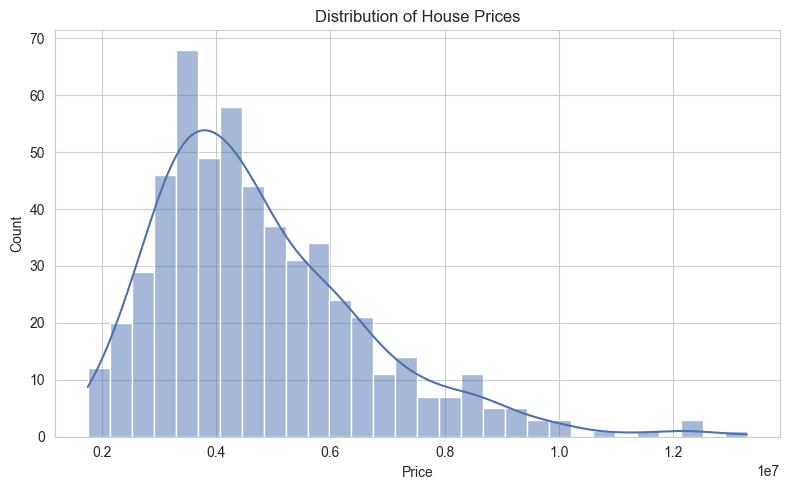

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("charts/chart1_price_distribution.png", dpi=150)
plt.show()

**Chart 2 — Correlation Heatmap**

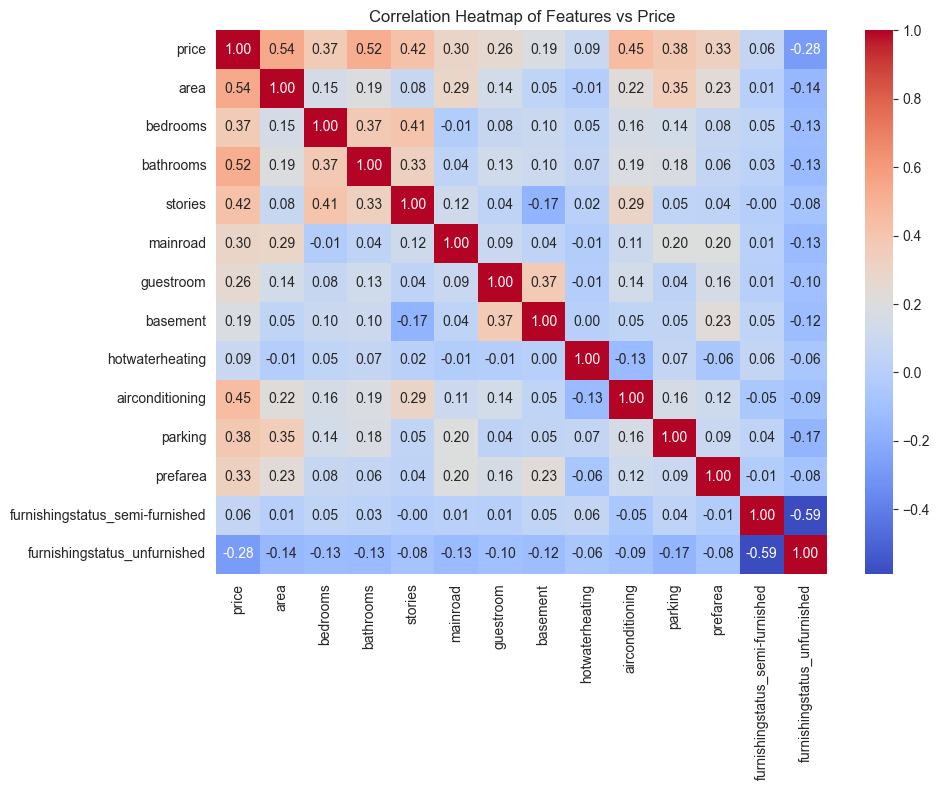

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Features vs Price")
plt.tight_layout()
plt.savefig("charts/chart2_correlation_heatmap.png", dpi=150)
plt.show()

**Chart 3(Scatter plot) — Actual vs Predicted Price (both models)**

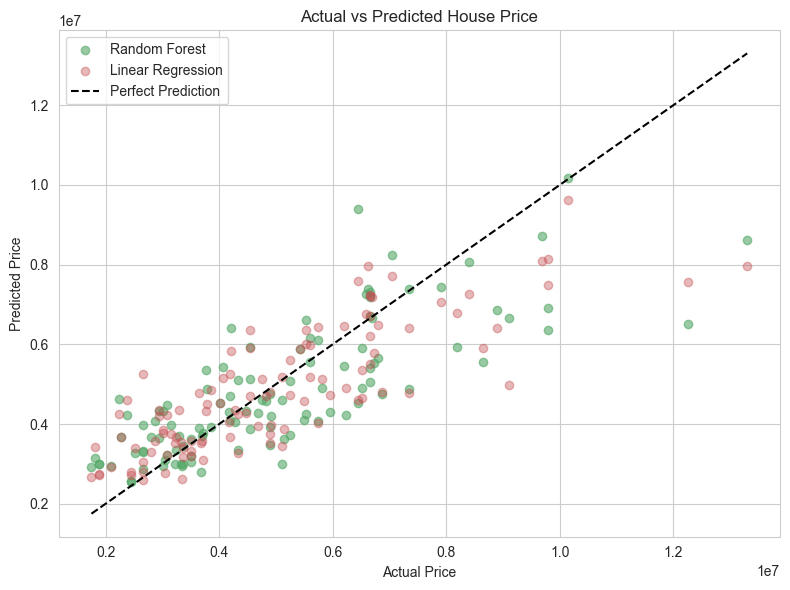

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_rf, alpha=0.6, color="#55A868", label="Random Forest")
plt.scatter(y_test, pred_lr, alpha=0.4, color="#C44E52", label="Linear Regression")
lims = [min(y_test.min(), pred_rf.min()), max(y_test.max(), pred_rf.max())]
plt.plot(lims, lims, "k--", label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.legend()
plt.tight_layout()
plt.savefig("charts/chart3_actual_vs_predicted.png", dpi=150)
plt.show()

## Task 5 — Insights & Summary

**Which features influence price the most?** `area` is by far the strongest driver (correlation ≈ 0.54, and the top feature in the Random Forest importance ranking at ~47%), followed by `bathrooms` (~0.52 correlation, ~15% importance) and `airconditioning` (~0.45 correlation). Number of `stories` and `parking` spaces also matter noticeably, while `hotwaterheating` and individual furnishing categories had the weakest standalone relationship with price.

**How accurate was the model?** The Linear Regression model explained about 65% of the variation in house prices (R² = 0.65) on data it hadn't seen, with a typical prediction error (MAE) of roughly ₹970,000 — meaningful, but reasonable given that location-specific factors (which this dataset doesn't capture) clearly also drive price. The Random Forest performed marginally worse here (R² = 0.61), likely because the dataset is small (545 rows) and the price relationship is largely linear, so the simpler model generalized slightly better.

**What was surprising?** `bathrooms` had a stronger relationship with price than `bedrooms` — bathroom count seems to act as a proxy for overall home quality/size more than raw bedroom count does. Also, a fully *unfurnished* status had a clear negative effect on price, while *semi-furnished* vs *furnished* made a smaller difference than expected.

**Recommendation for a real estate business:** Since `area` and `bathrooms` are the two biggest price levers, marketing listings should foreground square footage and bathroom count prominently, and renovation budgets aimed at boosting resale value should prioritize adding a bathroom or air conditioning over cosmetic furnishing upgrades, which had comparatively little measurable impact on price.